<a href="https://colab.research.google.com/github/elariekerboull/master_uppsala/blob/main/Machine%20Learning/Exercise_6_2_KERAS_complicated_function_solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 6.2 - Solution
## Interpolation
In this task, we implement a simple NN to learn a complicated function.

In [ ]:
import numpy as np
from tensorflow import keras
import matplotlib.pyplot as plt

layers = keras.layers

### Generation of data

In [ ]:
def some_complicated_function(x):
    return (
        (np.abs(x)) ** 0.5
        + 0.1 * x
        + 0.01 * x ** 2
        + 1
        - np.sin(x)
        + 0.5 * np.exp(x / 10.0)
        ) / (0.5 + np.abs(np.cos(x)))

Let's simulate the train data

In [ ]:
N_train = 10 ** 4  # number of training samples
# Note: "[:, np.newaxis]" reshapes array to (N,1) as required by our DNN (we input one feature per sample)
xtrain = np.random.uniform(-10, 10, N_train)[:, np.newaxis]
ytrain = some_complicated_function(xtrain) + np.random.standard_normal(xtrain.shape)  # train data includes some noise

In [ ]:
print("xtrain.shape", xtrain.shape)
print("ytrain.shape", ytrain.shape)

xtrain.shape (10000, 1)
ytrain.shape (10000, 1)


Simulate test data

In [ ]:
N_test = 10000  # number of testing samples
xtest = np.linspace(-10, 10, N_test)[:, np.newaxis]
ytest = some_complicated_function(xtest)

In [ ]:
print("xtest.shape", xtest.shape)
print("ytest.shape", ytest.shape)

xtest.shape (10000, 1)
ytest.shape (10000, 1)


### Define Model

In this case, we make use of a simple network with 5 layers. As activation function the ReLU is used. We further add parameter norm penalties (L1 and L2) as regularization strategy.

In [ ]:
nb_nodes = 32
nb_layers = 4
activation = "relu"
reg_strategy = keras.regularizers.l1_l2(l1=0.01, l2=0.01)  # use L1 and L2 regularization

model = keras.models.Sequential(name="1Dfit")
model.add(layers.Dense(nb_nodes, activation=activation, kernel_regularizer=reg_strategy,
                       input_dim=xtrain.shape[1]))

for i in range(nb_layers - 1):
    model.add(layers.Dense(nb_nodes, activation=activation, kernel_regularizer=reg_strategy))

model.add(layers.Dense(1))

print(model.summary())

Model: "1Dfit"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 32)                64        
                                                                 
 dense_1 (Dense)             (None, 32)                1056      
                                                                 
 dense_2 (Dense)             (None, 32)                1056      
                                                                 
 dense_3 (Dense)             (None, 32)                1056      
                                                                 
 dense_4 (Dense)             (None, 1)                 33        
                                                                 
Total params: 3265 (12.75 KB)
Trainable params: 3265 (12.75 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None


### Compile the model (set an objective and choose an optimizer)

In [ ]:
adam = keras.optimizers.Adam(learning_rate=0.001)  # learning rate = 0.001
model.compile(loss="MSE", optimizer=adam)

### Train the model

In [ ]:
epochs = 400
save_period = 50  # after how many epochs the model should be saved?

chkpnt_saver = keras.callbacks.ModelCheckpoint("weights-{epoch:02d}.weights.h5", save_weights_only=True, save_freq=save_period)

results = model.fit(
    xtrain,
    ytrain,
    batch_size=64,
    epochs=epochs,
    verbose=1,
    callbacks=[chkpnt_saver]
    )

Epoch 1/400
157/157 [==============================] - 0s 3ms/step - loss: 2.7543
Epoch 2/400
157/157 [==============================] - 0s 3ms/step - loss: 2.7485
Epoch 3/400
157/157 [==============================] - 0s 3ms/step - loss: 2.7438
Epoch 4/400
157/157 [==============================] - 0s 3ms/step - loss: 2.7437
Epoch 5/400
157/157 [==============================] - 0s 2ms/step - loss: 2.7371
Epoch 6/400
157/157 [==============================] - 0s 3ms/step - loss: 2.7358
Epoch 7/400
157/157 [==============================] - 0s 2ms/step - loss: 2.7321
Epoch 8/400
157/157 [==============================] - 0s 3ms/step - loss: 2.7270
Epoch 9/400
157/157 [==============================] - 0s 2ms/step - loss: 2.7208
Epoch 10/400
157/157 [==============================] - 0s 2ms/step - loss: 2.7157
Epoch 11/400
157/157 [==============================] - 0s 3ms/step - loss: 2.7233
Epoch 12/400
157/157 [==============================] - 0s 2ms/step - loss: 2.7252
Epoch 13/400


In [ ]:
print(results.history['loss'])

[2.754276752471924, 2.748509645462036, 2.743779182434082, 2.7436726093292236, 2.7371132373809814, 2.7357516288757324, 2.7320659160614014, 2.726972818374634, 2.72084641456604, 2.7157251834869385, 2.7232930660247803, 2.7251932621002197, 2.715205430984497, 2.7157797813415527, 2.70650577545166, 2.70797061920166, 2.70672869682312, 2.7107295989990234, 2.6981422901153564, 2.708355188369751, 2.7041192054748535, 2.6959187984466553, 2.696401357650757, 2.6973133087158203, 2.696185827255249, 2.6917879581451416, 2.6921846866607666, 2.689351797103882, 2.6827754974365234, 2.6793880462646484, 2.680809497833252, 2.6804280281066895, 2.68200945854187, 2.6706433296203613, 2.6778736114501953, 2.6777167320251465, 2.671112298965454, 2.674823045730591, 2.6668472290039062, 2.668567657470703, 2.6623966693878174, 2.6652774810791016, 2.66879940032959, 2.6621346473693848, 2.6624603271484375, 2.6658592224121094, 2.6639556884765625, 2.6669204235076904, 2.6615209579467773, 2.653489351272583, 2.665048360824585, 2.6624

Compare the performance of the model during the training.

313/313 [==============================] - 0s 2ms/step


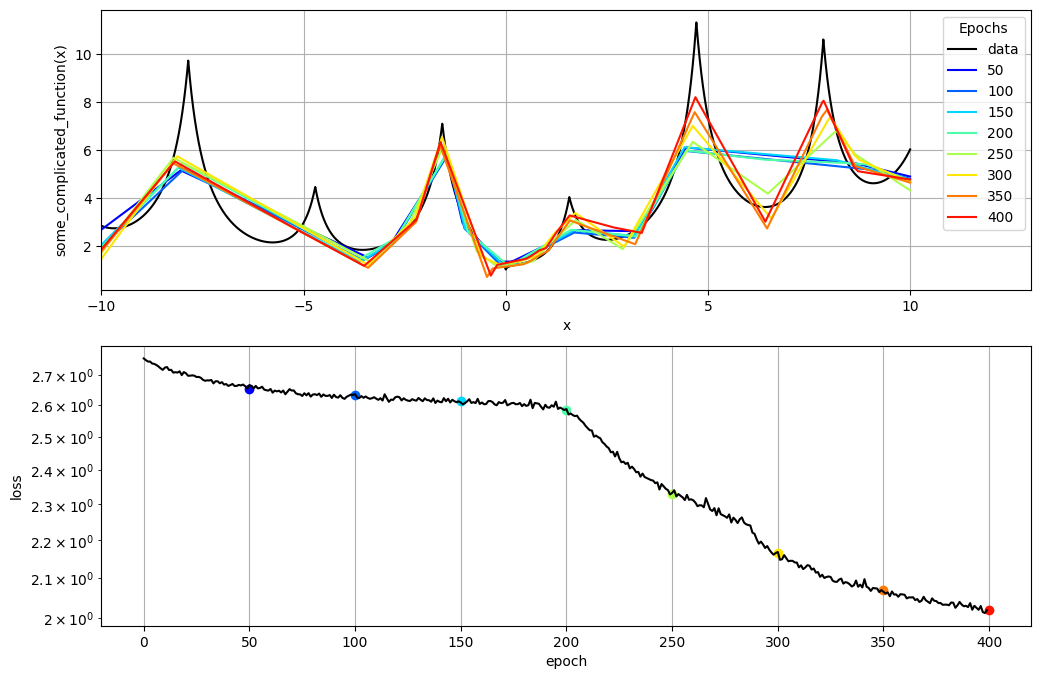

In [ ]:
fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(12, 8))

ax1.plot(xtest, ytest, color="black", label="data")
saved_epochs = range(save_period, epochs + 1, save_period)

colors = [plt.cm.jet((i + 1) / float(len(saved_epochs) + 1)) for i in range(len(saved_epochs))]

for i, epoch in enumerate(saved_epochs):
    model.load_weights("weights-{epoch:02d}.weights.h5".format(epoch=epoch))
    ypredict = model.predict(xtest).squeeze()
    ax1.plot(xtest.squeeze(), ypredict, color=colors[i], label=epoch)
    ax2.plot(epoch, results.history["loss"][epoch - 1], color=colors[i], marker="o")

ax1.set(xlabel="x", ylabel="some_complicated_function(x)", xlim=(-10, 13), title="")
ax1.grid(True)
ax1.legend(loc="upper right", title="Epochs")

ax2.plot(results.history["loss"], color="black")
ax2.set(xlabel="epoch", ylabel="loss")
ax2.grid(True)
ax2.semilogy()

plt.show()

As can be seen, with an increasing number of iterations, the performance of the DNN improves.
Additionally, it can be seen nicely that the ReLU activation function was used (sharp linear intervals).